___

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

___
**_Bitte beachten:_**

- In Code-Zellen soll (bei Bedarf kommentierter) Code eingefügt werden. In Raw-Zellen erwarten wir Antworten im Freitext-Format.
- Fragestellungen sind teilweise bewusst etwas offener formuliert, weil Sie auch im Arbeitsleben nur selten mit ganz spezifischen Anweisungen rechnen können.Es gibt häufig mehrere mögliche Lösungen, dies wird in der Korrektur  berücksichtigt.

___

# (I can't get no) satisfaction
Wir arbeiten weiterhin mit dem Datensatz über die Zufriedenheit von Angestellten einer fiktiven Firma. In dieser Kurseinheit werden wir einige Techniken zur Datenvisualisierung anwenden.

*Hinweise:*
- *Für die Visualisierungsaufgaben gibt es meist unterschiedliche Lösungswege. Wir verwenden in den meisten Fällen die Bibliothek `matplotlib`. Sie können die Aufgaben auch mit anderen Bibliotheken, wie z.B. `seaborn`, lösen. Denken Sie in dem Fall daran, die entsprechende Bibliothek zu installieren und zu importieren.*
- *Denken Sie bei der Erstellung der Plots an Titel und Achsenbeschriftung!*

**Daten laden**

Wir verwenden nun den transformierten Datensatz aus KE3. Sollten Sie die Aufgaben aus KE3 erfolgreich absolviert haben, können Sie Ihren Datensatz verwenden, ansonsten finden Sie die entsprechende csv-Datei (`employees_satisfaction_transformed.csv`) im Moodle.

In [2]:
# Datensatz laden
# Laden Sie den Datensatz wieder so, dass die erste Spalte als Index (Row Label) verwendet wird
# Wir verwenden hier den transformierten Datensatz aus KE3
df = pd.read_csv("../data/employees_satisfaction_transformed.csv", index_col=0)

***Hinweis zur Korrektur:*** *Die Lösung ist nur mit der Angabe von `index_col=0` als korrekt zu bewerten.*

Für Datumsberechnungen wandeln wir wieder den Datentyp von `entry_date` um.

In [3]:
df["entry_date"] = pd.to_datetime(df["entry_date"], format="%Y-%m-%d")

In [4]:
df

,age,department,education,recruitment_type,job_level,rating,awards,certifications,salary,gender,entry_date,satisfied
0,28,HR,Postgraduate,Referral,5,2.0,1,0,78075.0,Male,2019-02-01,1
1,50,Technology,Postgraduate,Recruitment Agency,3,5.0,2,1,38177.1,Male,2017-01-17,0
2,43,Technology,Undergraduate,Referral,4,1.0,2,0,59143.5,Female,2012-08-27,1
3,44,Sales,Postgraduate,On-Campus,2,3.0,0,0,26824.5,Female,2017-07-25,1
4,33,HR,Undergraduate,Recruitment Agency,2,1.0,5,0,26824.5,Male,2019-05-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...
495,49,HR,Postgraduate,On-Campus,2,5.0,6,0,26824.5,Male,2014-03-21,1
496,24,Technology,Undergraduate,Referral,2,4.0,2,0,26824.5,Female,2018-02-20,0
497,34,Marketing,Postgraduate,On-Campus,1,Unavailable,2,0,21668.4,Male,2020-10-20,1
498,26,Technology,Undergraduate,Walk-in,2,1.0,1,1,26824.5,Male,2012-05-18,0


## Data Analysis

### Alter

**Wie ist das durchschnittliche Alter der Angestellten? Unterscheidet sich dieses, in Abhängigkeit von der Abteilung?**

In [5]:
# Ihre Lösung
df["age"].mean()

39.670682730923694

In [6]:
df.groupby("department")["age"].mean()

department
HR            39.367925
Marketing     38.784946
Purchasing    40.140351
Sales         38.816092
Technology    41.051020
Name: age, dtype: float64

***Hinweis zur Korrektur:*** *Für eine valide Lösung muss das durchschnittliche Alter (aller Angestellten und in Abhängigkeit der Abteilung) korrekt berechnet sein und angegeben werden, dass es keine großen Unterschiede zwischen den Abteilungen gibt.*

**In welcher Abteilung arbeitet der älteste Mann, in welcher die jüngste Frau?**

In [ ]:
# Ihre Lösung

In [7]:
# Abteilung ältester Mann
males = df[df["gender"]=="Male"]
males[males["age"]==males["age"].max()]["department"]

68    Technology
Name: department, dtype: object

In [8]:
# Abteilung jüngste Frau
females = df[df["gender"]=="Female"]
females[females["age"]==females["age"].min()]["department"]

276    HR
Name: department, dtype: object

***Hinweis zur Korrektur:*** *Es muss darauf geachtet werden, dass bei der Abfrage korrekt nach den Daten der Männer/Frauen gefiltert wurde. Es muss angegeben werden, dass der älteste Mann in "Technology" arbeitet und die jüngste Frau in "HR".*

### Awards

**Wie ist die durchschnittliche Anzahl Awards? Wie ist der Median? Welcher Wert ist aussagekräftiger?**

In [ ]:
# Ihre Lösung

In [9]:
# Mean
df["awards"].mean()

4.586345381526105

In [10]:
# Median
df["awards"].median()

5.0

***Hinweis zur Korrektur:*** *Es ist auch ok, wenn angegeben wird, dass beide Werte zusammen aussagekräftig sind. Es sollte jedoch immer eine Begründung angegeben werden.*

### Zufriedenheit

**In welcher Abteilung sind die meisten zufriedenen Angestellten?**

In [11]:
# Ihre Lösung
df[df["satisfied"]==1].groupby("department").size().sort_values(ascending=False)

department
Purchasing    80
HR            73
Technology    73
Sales         70
Marketing     60
dtype: int64

**Und in welcher Abteilung sind die Angestellten im Schnitt am zufriedensten?**

In [12]:
# Ihre Lösung
df.groupby("department")["satisfied"].mean().sort_values(ascending=False)

department
Sales         0.804598
Technology    0.744898
Purchasing    0.701754
HR            0.688679
Marketing     0.645161
Name: satisfied, dtype: float64

### Fairness

**Gender Pay Gap**

Bekommen Männer und Frauen der fiktiven Firma das gleiche Gehalt?

In [ ]:
# Ihre Analysen

In [13]:
# Gehalt <-> Geschlecht
df.groupby("gender")["salary"].mean()

gender
Female     43627.387500
Male       47042.079468
Unknown    46651.800000
Name: salary, dtype: float64

In [14]:
df.groupby(["gender", "job_level"])["salary"].mean()

gender   job_level
Female   1            21668.4
         2            26824.5
         3            38177.1
         4            59143.5
         5            78075.0
Male     1            21668.4
         2            26824.5
         3            38177.1
         4            59143.5
         5            78075.0
Unknown  1            21668.4
         4            59143.5
Name: salary, dtype: float64

In [15]:
df.groupby(["gender", "job_level"]).size()

gender   job_level
Female   1            49
         2            51
         3            38
         4            58
         5            36
Male     1            45
         2            57
         3            44
         4            50
         5            67
Unknown  1             1
         4             2
dtype: int64

***Hinweis zur Korrektur:*** *Damit die Aufgabe als korrekt bewertet wird, muss erkannt werden, dass alle Personen innerhalb eines Job Levels das gleiche Gehalt bekommen, unabhängig vom Geschlecht.*

Betrachten Sie den Datensatz weiterhin mit Fokus auf dem Thema *Fairness*. Was fällt Ihnen auf? Welche Aspekte könnte man noch untersuchen?

In [ ]:
# Ihre Analysen

In [16]:
# Zufriedenheit <-> Geschlecht
df.groupby(["gender", "satisfied"]).size()

gender   satisfied
Female   0             66
         1            166
Male     0             74
         1            189
Unknown  0              2
         1              1
dtype: int64

In [17]:
print(f"Female: satisfied: {round(len(females[females.satisfied==1])/len(females), 2)} / unsatisfied: {round(len(females[females.satisfied==0])/len(females), 2)}")
print(f"Male: satisfied: {round(len(males[males.satisfied==1])/len(males), 2)} / unsatisfied: {round(len(males[males.satisfied==0])/len(males), 2)}")

Female: satisfied: 0.72 / unsatisfied: 0.28
Male: satisfied: 0.72 / unsatisfied: 0.28


In [18]:
# Job-Level <-> Geschlecht
df.groupby(["gender", "job_level"]).size()

gender   job_level
Female   1            49
         2            51
         3            38
         4            58
         5            36
Male     1            45
         2            57
         3            44
         4            50
         5            67
Unknown  1             1
         4             2
dtype: int64

**Hinweis zur Korrektur:** *Hier sind unterschiedliche Arten von Analysen denkbar. Es reicht als richtige Lösung, wenn die Studierenden einen (begründeten) Aspekt genannt haben. Dieser kann auch über die hier genannten Beispiele hinausgehen (es gilt nur immer: es muss gut begründet sein).*

## Data Visualization

**Hinweise zur Korrektur:** *Folgende Aspekte sollten mit in die Bewertung einbezogen werden: Die korrekte Darstellung mittels des geforderten Diagrammtyps, sinnvolle Achsenbeschriftungen/Titel/ggf. Legende und eine korrekte Interpretation des Diagramms. Sollten die Beschriftungen konsequent weggelassen worden sein, sollten hierfür Teilpunkte abgezogen werden, da sie von Bedeutung für die Lesbarkeit und Interpretation der Visualisierungen sind.*

### Säulendiagramm

Zur Erinnerung (siehe Buch S.335): Es gelten folgende Aspekte bei Säulendiagrammen:

> **Regel**: Die Säulen müssen bei 0 anfangen!

> **Richtlinie**: Vertikale Balken eignen sich gut für dichtere Daten mit weniger Schwankungen.

> **Richtlinie**: Horizontale Balken sind besser für mehr Variation und/oder längere Labels.

Beschreiben Sie für die folgenden Aufgabenstellungen neben Ihrer Interpretation des Diagramme auch, ob Säulendiagramme für die Fragestellung geeignet sind und wenn nicht, welche Regel/Richtlinien verletzt sind. Entscheiden Sie für jeden Aufgabenstellung selbst, ob Sie horizontale oder vertikale Balken/Säulen wählen und begründen Sie Ihre Entscheidung!

**In welchem Department arbeiten die meisten Personen?**

Erstellen Sie zur Beantwortung der Frage ein Säulendiagramm, das die Anzahl Angestellte pro Department darstellt.

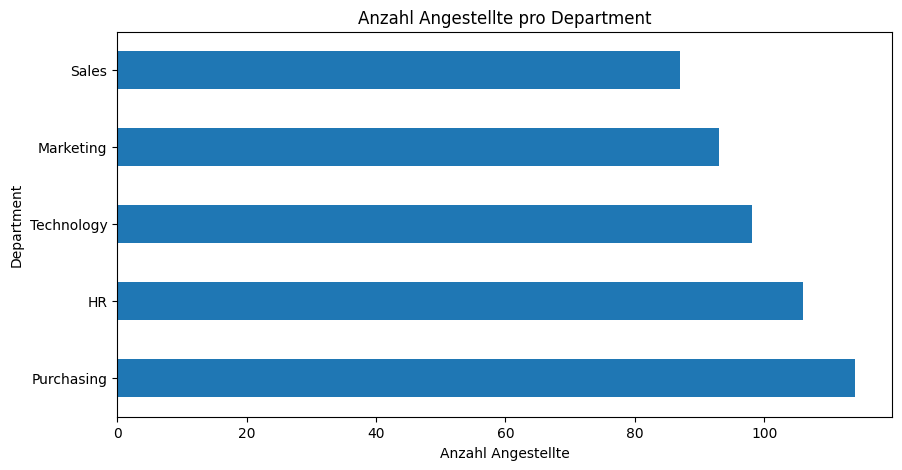

In [19]:
# Ihre Lösung
df['department'] \
    .value_counts() \
    .plot.barh(figsize=(10,5), title="Anzahl Angestellte pro Department", xlabel="Anzahl Angestellte", ylabel="Department")
plt.show()

**Unterscheidet sich die durchschnittliche Anzahl Awards, in Abhängigkeit von der Ausbildung, stark?**

Erstellen Sie hierfür wiederum ein Säulendiagramm.

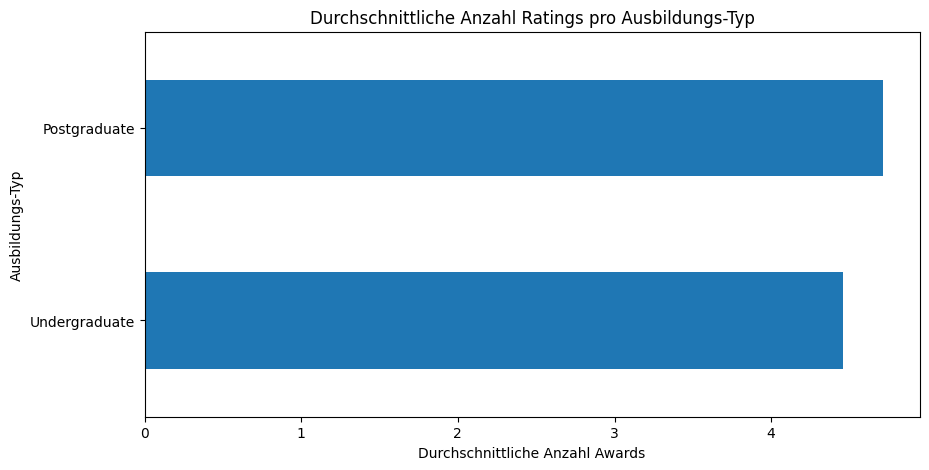

In [20]:
# Ihre Lösung
df \
    .groupby("education")["awards"] \
    .mean() \
    .sort_values() \
    .plot.barh(figsize=(10,5), title="Durchschnittliche Anzahl Ratings pro Ausbildungs-Typ", xlabel="Durchschnittliche Anzahl Awards", ylabel="Ausbildungs-Typ")
plt.show()

**Sind Angestellte mit einem höheren Gehalt im Schnitt zufriedener?**

Erstellen Sie hierzu ein Säulendiagramm, das pro Gehaltsklasse die durchschnittliche Zufriedenheit angibt.

***Hinweis zur Korrektur:*** *An dieser Stelle hatte sich ein Tippfehler eingeschlichen und es war versehentlich ein Liniendiagramm gefordert. An dieser Stelle wurden deshalb sowohl Abgaben mit einem Säulendiagramm als auch mit einem Liniendiagramm akzeptiert. Die Musterlösung haben wir für dieses Semester um die Lösung mittels Liniendiagramm erweitert.*

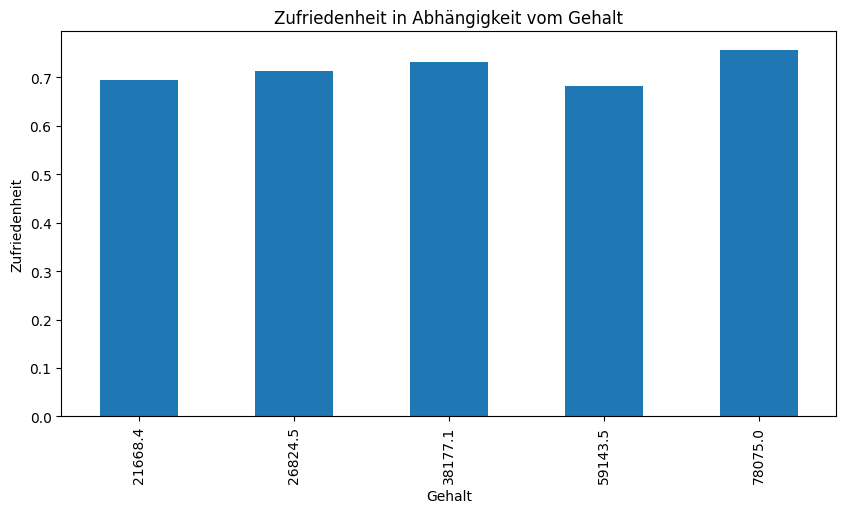

In [21]:
# Ihre Lösung
df \
    .groupby("salary")["satisfied"] \
    .mean() \
    .plot(kind="bar", figsize=(10,5), title="Zufriedenheit in Abhängigkeit vom Gehalt", xlabel="Gehalt", ylabel="Zufriedenheit")
plt.show()

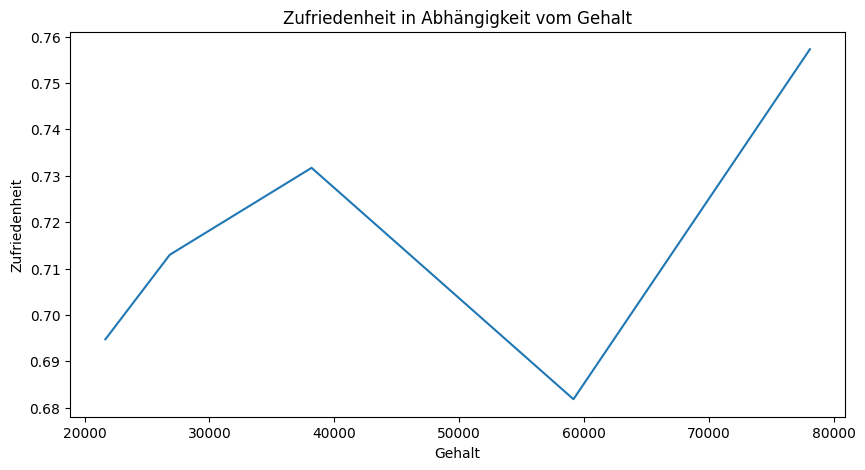

In [22]:
# Ihre Lösung
df \
    .groupby("salary")["satisfied"] \
    .mean() \
    .plot(kind="line", figsize=(10,5), title="Zufriedenheit in Abhängigkeit vom Gehalt", xlabel="Gehalt", ylabel="Zufriedenheit")
plt.show()

### Liniendiagramm

Zur Erinnerung (siehe Buch S.339): Es gelten folgende Aspekte bei Liniendiagrammen:

> **Regel**: Die Datenpunkte müssen Werte im *Zeitverlauf* darstellen.

> **Richtlinie**: Die Datenpunkte sollten etwa 2/3 des vertikalen Diagrammbereichs einnehmen.

> **Richtlinie**: Vier oder weniger Zeilen sollten deutlich gefärbt/beschriftet sein.

Beschreiben Sie für die folgenden Aufgabenstellungen neben Ihrer Interpretation des Diagramme auch, ob Liniendiagramme für die Fragestellung geeignet sind und wenn nicht, welche Regel/Richtlinien verletzt sind.

**Steigt das durchschnittliche Alter pro Job-Level, fällt es oder bleibt es ungefähr gleich?**

Beantworten Sie diese Frage mithilfe eines Liniendiagramms.

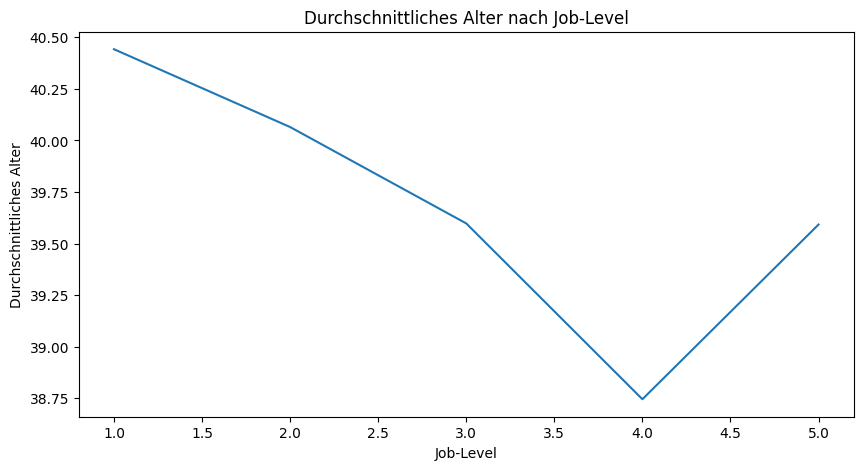

In [23]:
# Ihre Lösung
df \
    .groupby(["job_level"])["age"] \
    .mean() \
    .plot(kind="line", figsize=(10,5), title="Durchschnittliches Alter nach Job-Level", xlabel="Job-Level", ylabel="Durchschnittliches Alter")
plt.show()

**Verändert sich das Recruiting über die Jahre?**

Erstellen Sie hierzu ein Liniendiagramm, das die Anzahl der Neuanstellungen über die Zeit (`entry_date`) in Abhängigkeit vom Recruitment-Typ darstellt.

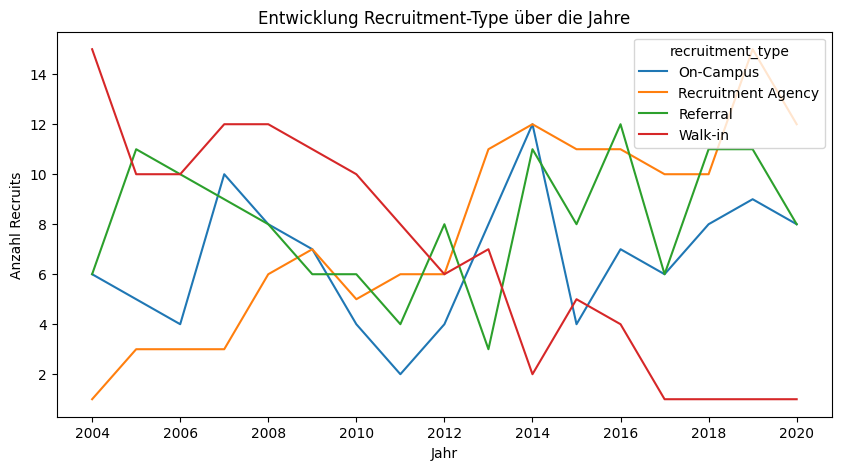

In [24]:
# Ihre Lösung
df \
    .groupby([df["entry_date"].dt.year, df["recruitment_type"]]) \
    .size() \
    .unstack("recruitment_type") \
    .plot(kind="line", figsize=(10,5), title="Entwicklung Recruitment-Type über die Jahre", xlabel="Jahr", ylabel="Anzahl Recruits")
plt.show()

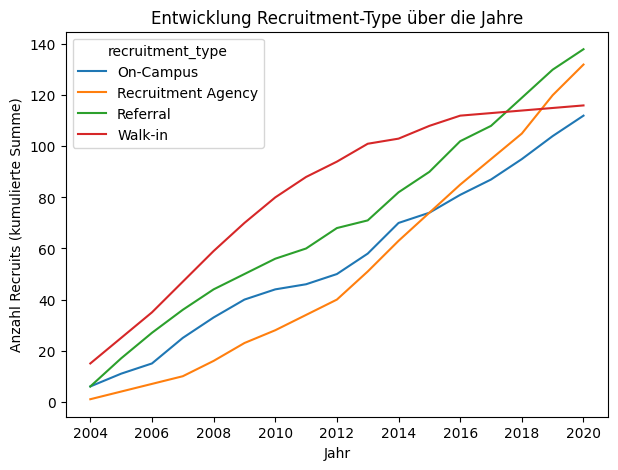

In [25]:
# Alternative Lösung
df.groupby([df["entry_date"].dt.year, df["recruitment_type"]]).size() \
  .groupby(level=1).cumsum() \
  .unstack("recruitment_type") \
  .plot(kind="line", figsize=(7,5), title="Entwicklung Recruitment-Type über die Jahre", xlabel="Jahr", ylabel="Anzahl Recruits (kumulierte Summe)")
plt.show()

**Hinweise zur Korrektur:** *Bei der alternativen Lösung ist die Entwicklung nicht ganz so eindeutig zu erkennen, deshalb bitte insbesondere hier auf eine korrekte Interpretation achten.*

**Sind Angestellte, die schon länger in der Firma sind, im Schnitt zufriedener?**

Beantworten Sie diese Frage ebenfalls mithilfe eines Liniendiagramms. Gruppieren Sie die Angestellten dafür nach dem Einstellungsjahr (`df["entry_date"].dt.year`).

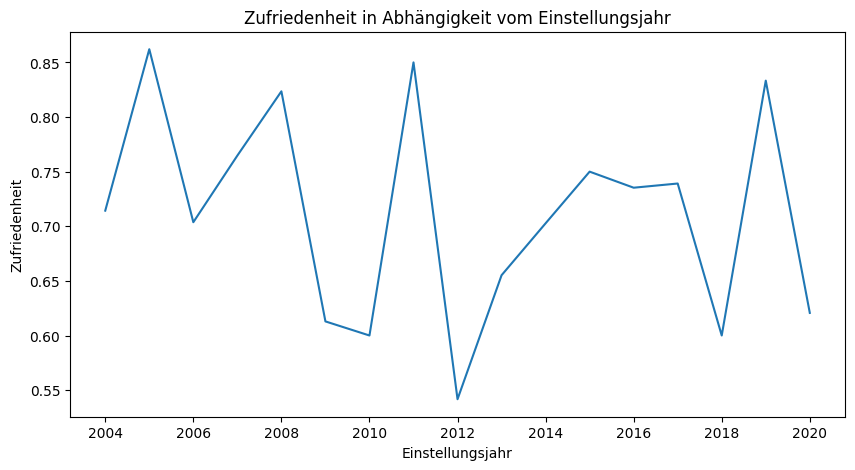

In [26]:
# Ihre Lösung
df \
    .groupby(df["entry_date"].dt.year)["satisfied"] \
    .mean() \
    .plot(kind="line", figsize=(10,5), title="Zufriedenheit in Abhängigkeit vom Einstellungsjahr", xlabel="Einstellungsjahr", ylabel="Zufriedenheit")
plt.show()

### Kreisdiagramm

Zur Erinnerung (siehe Buch S.330): Es gelten folgende Aspekte bei Liniendiagrammen:

> **Regel**: Die Datenkategorien müssen konzeptionell ein einziges "Ganzes" ergeben.

> **Richtlinie**: Die Anzahl der Kategorien sollte auf fünf oder weniger reduziert werden.

> **Richtlinie**: Der Anteil der hervorzuhebenden Daten sollte 1/4, 1/3, 1/2, 2/3 oder 3/4 der Gesamtmenge betragen.

Beschreiben Sie für die folgenden Aufgabenstellungen neben Ihrer Interpretation des Diagramme auch, ob Kreisdiagramme für die Fragestellung geeignet sind und wenn nicht, welche Regel/Richtlinien verletzt sind.

**Gibt es Abteilungen, in denen mehr Frauen als Männer arbeiten?**

Beantworten Sie diese Frage mithilfe von Kreisdiagrammen (ein Kreisdiagramm pro Abteilung).

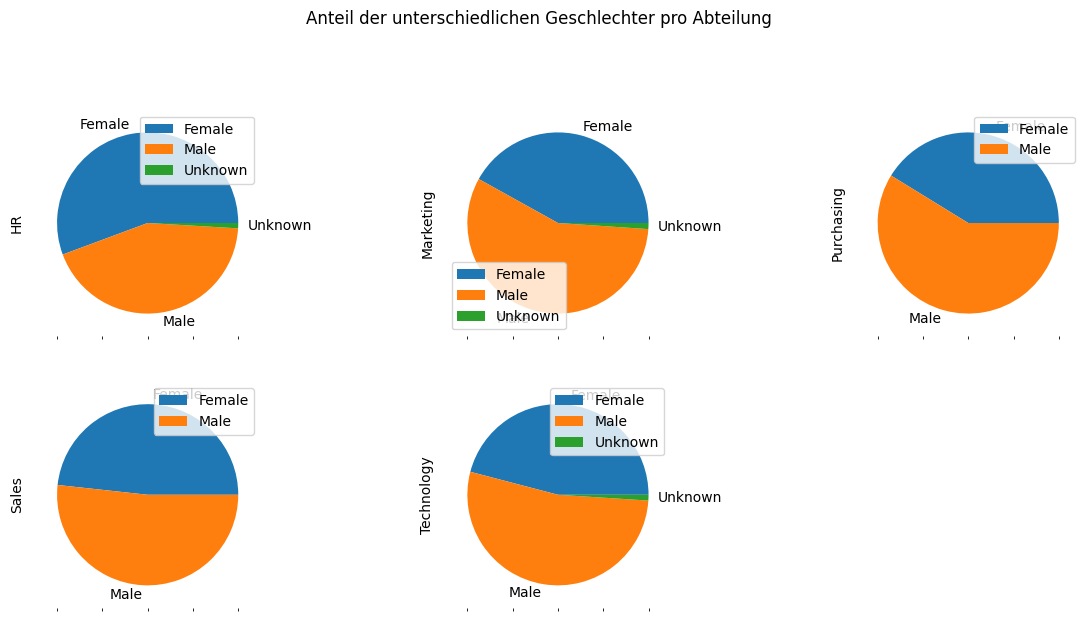

In [27]:
# Ihre Lösung
df \
    .groupby(['gender', 'department']) \
    .size() \
    .unstack("department") \
    .plot \
    .pie(subplots=True, figsize=(15,10), layout=(3, 3), title="Anteil der unterschiedlichen Geschlechter pro Abteilung")
plt.show()

**In Abhängigkeit vom Education-Typ: Welche Angestellten haben mehr Awards?**

Beantworten Sie diese Frage mithilfe von Kreisdiagrammen (ein Kreisdiagramm pro Education-Typ).

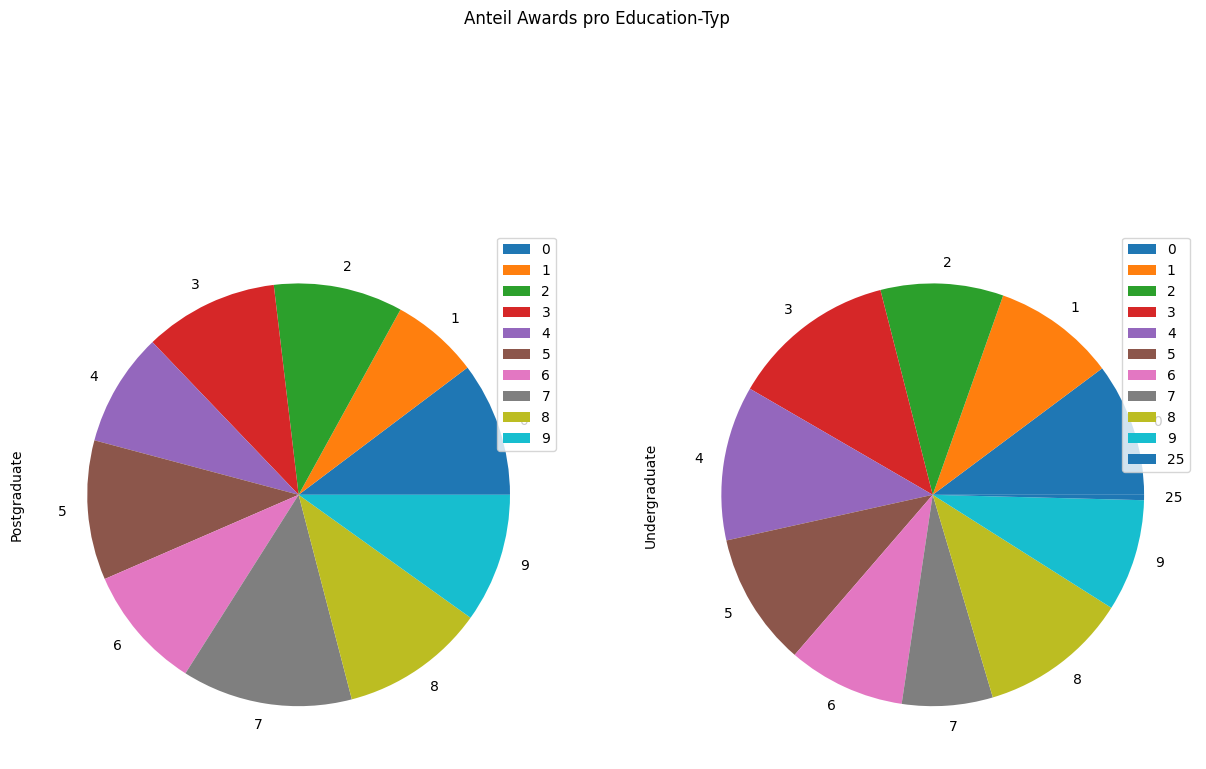

In [28]:
# Ihre Lösung
df \
    .groupby(['awards', 'education']) \
    .size() \
    .unstack("education") \
    .plot \
    .pie(subplots=True, figsize=(15,10), layout=(1, 2), title="Anteil Awards pro Education-Typ")
plt.show()